1. SETUP

In [43]:
# Librerías base del análisis
import os
import sys
import importlib

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Detecta la raíz del proyecto.
# Como este notebook está dentro de /notebooks,
# usamos ".." para subir un nivel hasta Proyecto_MBD
# ---------------------------------------------------
PROJECT_ROOT = os.path.abspath("..")

# ---------------------------------------------------
# Agrega la raíz del proyecto al path de Python
# para poder importar módulos propios como:
# utils.config
# services.ingestion.ingestion_service
# ---------------------------------------------------
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# ---------------------------------------------------
# Importa el archivo de configuración del proyecto
# y lo recarga por si hiciste cambios recientes
# ---------------------------------------------------
import utils.config as config
importlib.reload(config)

# ---------------------------------------------------
# Importa el servicio de ingestión que ya adaptamos
# para leer múltiples archivos CSV
# ---------------------------------------------------
from services.ingestion.ingestion_service import IngestionService

# ---------------------------------------------------
# Muestra por pantalla la ruta donde están los 23 CSV
# y el porcentaje configurado para el muestreo del EDA
# ---------------------------------------------------
print("FULL_DATASET_DIR:", config.FULL_DATASET_DIR)
print("EDA_SAMPLE_FRAC:", config.EDA_SAMPLE_FRAC)

FULL_DATASET_DIR: /home/bryan_santanderaragon/Proyecto_MBD/data/processed
EDA_SAMPLE_FRAC: 0.05


2. CARGAR MUESTRAS DE LOS 23 DATASETS

In [44]:
# ---------------------------------------------------
# Crea una instancia del servicio de ingestión
# En este caso no necesita un data_path único
# porque leeremos múltiples CSV desde una carpeta
# ---------------------------------------------------
ingestion = IngestionService()

# ---------------------------------------------------
# Carga una muestra de cada uno de los 23 archivos CSV.
# sample_frac=0.10 significa tomar el 10% de cada archivo.
# Esto permite hacer EDA sin cargar millones de filas completas.
# ---------------------------------------------------
df_full_sample = ingestion.load_multiple_csv_sample(
    folder_path=config.FULL_DATASET_DIR,
    sample_frac=0.10
)

# ---------------------------------------------------
# Muestra el tamaño del dataframe resultante
# y las primeras filas para inspección rápida
# ---------------------------------------------------
print("Shape muestra full:", df_full_sample.shape)
df_full_sample.head()

Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_1.csv


/home/bryan_santanderaragon/Proyecto_MBD/services/ingestion/ingestion_service.py:51: DtypeWarning: Columns (0: src_bytes) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_10.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_11.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_12.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_13.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_14.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_15.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_16.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_17.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_18.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_19.csv


/home/bryan_santanderaragon/Proyecto_MBD/services/ingestion/ingestion_service.py:51: DtypeWarning: Columns (0: src_bytes) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_23.csv


/home/bryan_santanderaragon/Proyecto_MBD/services/ingestion/ingestion_service.py:51: DtypeWarning: Columns (0: src_bytes) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_3.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_4.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_5.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_6.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_7.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_8.csv
Cargando muestra de: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/Network_dataset_9.csv
Shape muestra full: (2233902, 47)


,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type,uid
0,1556025777,192.168.1.32,50266,192.168.1.186,27228,tcp,-,0.0,0,0,...,0,-,-,-,-,-,-,1,scanning,NaN
1,1554273808,127.0.0.1,42100,127.0.0.1,7878,tcp,-,0.0,0,0,...,0,-,-,-,-,-,-,0,normal,NaN
2,1556025649,192.168.1.152,34422,192.168.1.32,10644,tcp,-,0.0,0,0,...,0,-,-,-,-,-,-,1,scanning,NaN
3,1556025616,192.168.1.30,22069,192.168.1.180,33883,tcp,-,0.0,0,0,...,0,-,-,-,-,-,-,1,scanning,NaN
4,1554258881,192.168.1.79,39062,192.168.1.255,15600,udp,-,0.0,0,0,...,0,-,-,-,-,-,-,0,normal,NaN


3. INFORMACIÓN GENERAL DEL DATAFRAME

In [45]:
# ---------------------------------------------------
# Muestra:
# - cantidad de filas y columnas
# - tipos de datos
# - conteo de valores no nulos
# Sirve para entender la estructura del dataset
# ---------------------------------------------------
df_full_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 2233902 entries, 0 to 2233901
Data columns (total 47 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   ts                      int64  
 1   src_ip                  str    
 2   src_port                int64  
 3   dst_ip                  str    
 4   dst_port                int64  
 5   proto                   str    
 6   service                 str    
 7   duration                float64
 8   src_bytes               object 
 9   dst_bytes               int64  
 10  conn_state              str    
 11  missed_bytes            int64  
 12  src_pkts                int64  
 13  src_ip_bytes            int64  
 14  dst_pkts                int64  
 15  dst_ip_bytes            int64  
 16  dns_query               str    
 17  dns_qclass              int64  
 18  dns_qtype               int64  
 19  dns_rcode               int64  
 20  dns_AA                  str    
 21  dns_RD                  str    
 22  dns_R

4. TIPOS DE VARIABLES

In [46]:
# ---------------------------------------------------
# Muestra:
# - cantidad de filas y columnas
# - tipos de datos
# - conteo de valores no nulos
# Sirve para entender la estructura del dataset
# ---------------------------------------------------
df_full_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 2233902 entries, 0 to 2233901
Data columns (total 47 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   ts                      int64  
 1   src_ip                  str    
 2   src_port                int64  
 3   dst_ip                  str    
 4   dst_port                int64  
 5   proto                   str    
 6   service                 str    
 7   duration                float64
 8   src_bytes               object 
 9   dst_bytes               int64  
 10  conn_state              str    
 11  missed_bytes            int64  
 12  src_pkts                int64  
 13  src_ip_bytes            int64  
 14  dst_pkts                int64  
 15  dst_ip_bytes            int64  
 16  dns_query               str    
 17  dns_qclass              int64  
 18  dns_qtype               int64  
 19  dns_rcode               int64  
 20  dns_AA                  str    
 21  dns_RD                  str    
 22  dns_R

5. VALORES NULOS

In [47]:
# ---------------------------------------------------
# Calcula cuántos valores nulos tiene cada columna
# y los ordena de mayor a menor
# Solo muestra las 20 columnas con más nulos
# ---------------------------------------------------
nulls = df_full_sample.isnull().sum().sort_values(ascending=False)
nulls[nulls > 0].head(20)

uid    2133902
dtype: int64

6. DISTRIBUCIÓN DE VARIABLES OBJETIVO

In [48]:
# ---------------------------------------------------
# Muestra cuántos registros hay por clase en 'label'
# Normalmente:
# 0 = normal
# 1 = ataque
# ---------------------------------------------------
print("Label:")
print(df_full_sample["label"].value_counts())

# ---------------------------------------------------
# Muestra cuántos registros hay por tipo de ataque en 'type'
# Esto permite ver el desbalance entre clases
# ---------------------------------------------------
print("\nType:")
print(df_full_sample["type"].value_counts())

Label:
label
1    2154082
0      79820
Name: count, dtype: int64

Type:
type
scanning      713935
ddos          616392
dos           337368
xss           210839
password      171839
normal         79820
backdoor       50796
injection      45417
ransomware      7386
mitm             110
Name: count, dtype: int64


7. VISUALIZACIÓN DE TIPOS DE ATAQUE

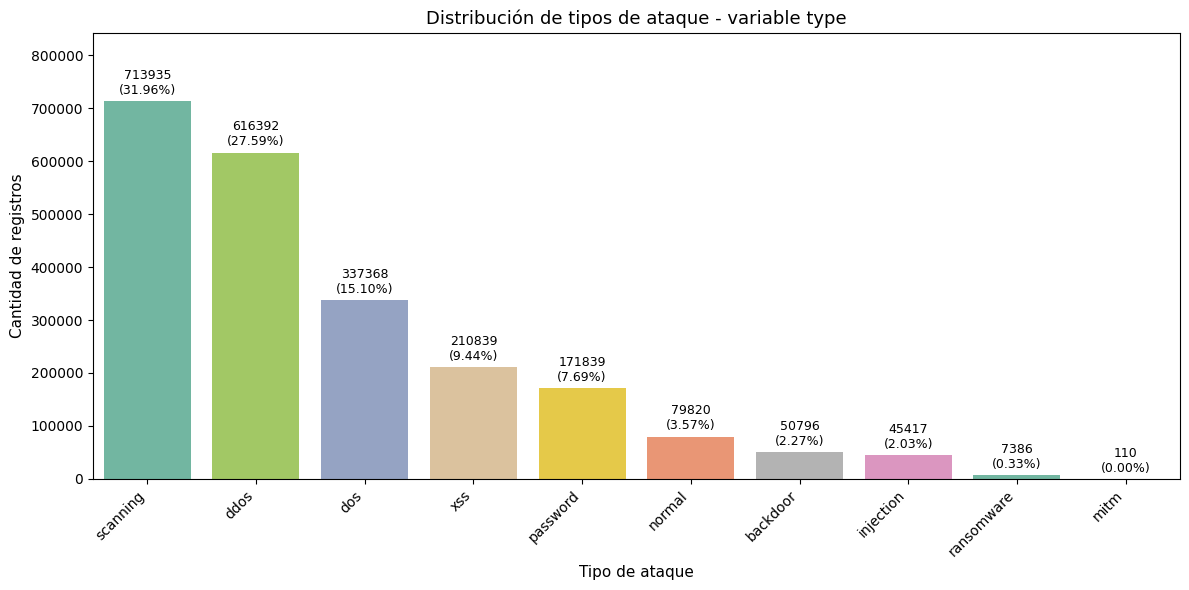

Imagen guardada en: ../images/figura_01_distribucion_tipos_ataque_variable_type.png


In [59]:
# ---------------------------------------------------
# Gráfico de barras con la cantidad de registros
# por cada tipo de ataque o clase
# Se ordena de mayor a menor frecuencia
# ---------------------------------------------------
# Si estás dentro de notebooks/, esto guarda en Proyecto_MBD/images/
import os
import matplotlib.pyplot as plt
import seaborn as sns

IMAGE_DIR = "../images"
os.makedirs(IMAGE_DIR, exist_ok=True)

ruta_imagen = os.path.join(
    IMAGE_DIR,
    "figura_01_distribucion_tipos_ataque_variable_type.png"
)

orden_tipos = df_full_sample["type"].value_counts().index
total = len(df_full_sample)

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_full_sample,
    x="type",
    hue="type",
    order=orden_tipos,
    palette="Set2",
    legend=False
)

# Agregar cantidad + porcentaje sobre cada barra
for patch in ax.patches:
    altura = patch.get_height()
    if altura > 0:
        porcentaje = (altura / total) * 100
        ax.annotate(
            f"{int(altura)}\n({porcentaje:.2f}%)",
            (patch.get_x() + patch.get_width() / 2, altura),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

ax.set_ylim(0, df_full_sample["type"].value_counts().max() * 1.18)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.title("Distribución de tipos de ataque - variable type", fontsize=13)
plt.xlabel("Tipo de ataque", fontsize=11)
plt.ylabel("Cantidad de registros", fontsize=11)

plt.tight_layout()

plt.savefig(
    ruta_imagen,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Imagen guardada en: {ruta_imagen}")

8. VISUALIZACIÓN NORMAL VS ATAQUE

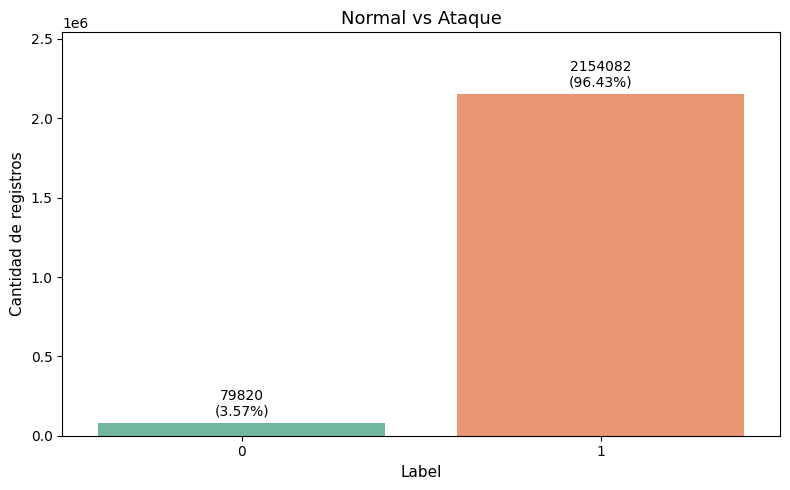

Imagen guardada en: ../images/figura_02_distribucion_label_normal_vs_ataque.png


In [62]:
# ---------------------------------------------------
# Gráfico de barras para ver la proporción
# entre tráfico normal y tráfico de ataque
# ---------------------------------------------------

IMAGE_DIR = "../images"
os.makedirs(IMAGE_DIR, exist_ok=True)

ruta_imagen = os.path.join(
    IMAGE_DIR,
    "figura_02_distribucion_label_normal_vs_ataque.png"
)

orden_label = [0, 1]
total = len(df_full_sample)

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_full_sample,
    x="label",
    hue="label",
    order=orden_label,
    palette="Set2",
    legend=False
)

for patch in ax.patches:
    altura = patch.get_height()
    if altura > 0:
        porcentaje = (altura / total) * 100
        ax.annotate(
            f"{int(altura)}\n({porcentaje:.2f}%)",
            (patch.get_x() + patch.get_width() / 2, altura),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points"
        )

ax.set_ylim(0, df_full_sample["label"].value_counts().max() * 1.18)

plt.title("Normal vs Ataque", fontsize=13)
plt.xlabel("Label", fontsize=11)
plt.ylabel("Cantidad de registros", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.savefig(
    ruta_imagen,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Imagen guardada en: {ruta_imagen}")

9. VARIABLES CATEGÓRICAS Y NUMÉRICAS

In [51]:
# ---------------------------------------------------
# Extrae columnas categóricas:
# object, string o category
# ---------------------------------------------------
categorical_cols = df_full_sample.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

# ---------------------------------------------------
# Extrae columnas numéricas:
# int, float, etc.
# ---------------------------------------------------
numeric_cols = df_full_sample.select_dtypes(
    include=["number"]
).columns.tolist()

# ---------------------------------------------------
# Muestra el listado de categóricas
# y la cantidad de columnas numéricas
# ---------------------------------------------------
print("Categóricas:", categorical_cols)
print("Numéricas:", len(numeric_cols))

Categóricas: ['src_ip', 'dst_ip', 'proto', 'service', 'src_bytes', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_referrer', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'type', 'uid']
Numéricas: 17


10. ESTADÍSTICA DESCRIPTIVA BÁSICA

In [52]:
# ---------------------------------------------------
# Genera estadísticas descriptivas para columnas numéricas:
# - media
# - desviación estándar
# - mínimos y máximos
# - percentiles
# Esto ayuda a detectar escalas distintas y posibles outliers
# ---------------------------------------------------
df_full_sample[numeric_cols].describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
ts,2233902.0,1.556170e+09,2.155704e+05,1.554198e+09,1.556078e+09,1.556181e+09,1.556253e+09,1.556549e+09
src_port,2233902.0,3.827994e+04,1.932052e+04,0.000000e+00,3.344400e+04,4.343200e+04,5.293800e+04,6.553500e+04
dst_port,2233902.0,6.535932e+03,1.404657e+04,0.000000e+00,8.000000e+01,4.430000e+02,4.821000e+03,6.553500e+04
duration,2233902.0,8.621608e+00,9.082870e+01,0.000000e+00,0.000000e+00,2.020000e-04,1.742867e-01,9.278995e+04
dst_bytes,2233902.0,7.765477e+05,3.373398e+07,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.467198e+09
missed_bytes,2233902.0,7.172917e+04,1.066036e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.271054e+09
src_pkts,2233902.0,4.519378e+00,5.116215e+02,0.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,7.103280e+05
src_ip_bytes,2233902.0,8.656978e+02,7.057128e+05,0.000000e+00,4.400000e+01,4.800000e+01,1.640000e+02,1.053479e+09
dst_pkts,2233902.0,2.633698e+00,5.677798e+02,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,8.220170e+05
dst_ip_bytes,2233902.0,5.852206e+02,9.540415e+04,0.000000e+00,0.000000e+00,4.000000e+01,1.200000e+02,1.269484e+08


11. MATRIZ DE CORRELACIÓN

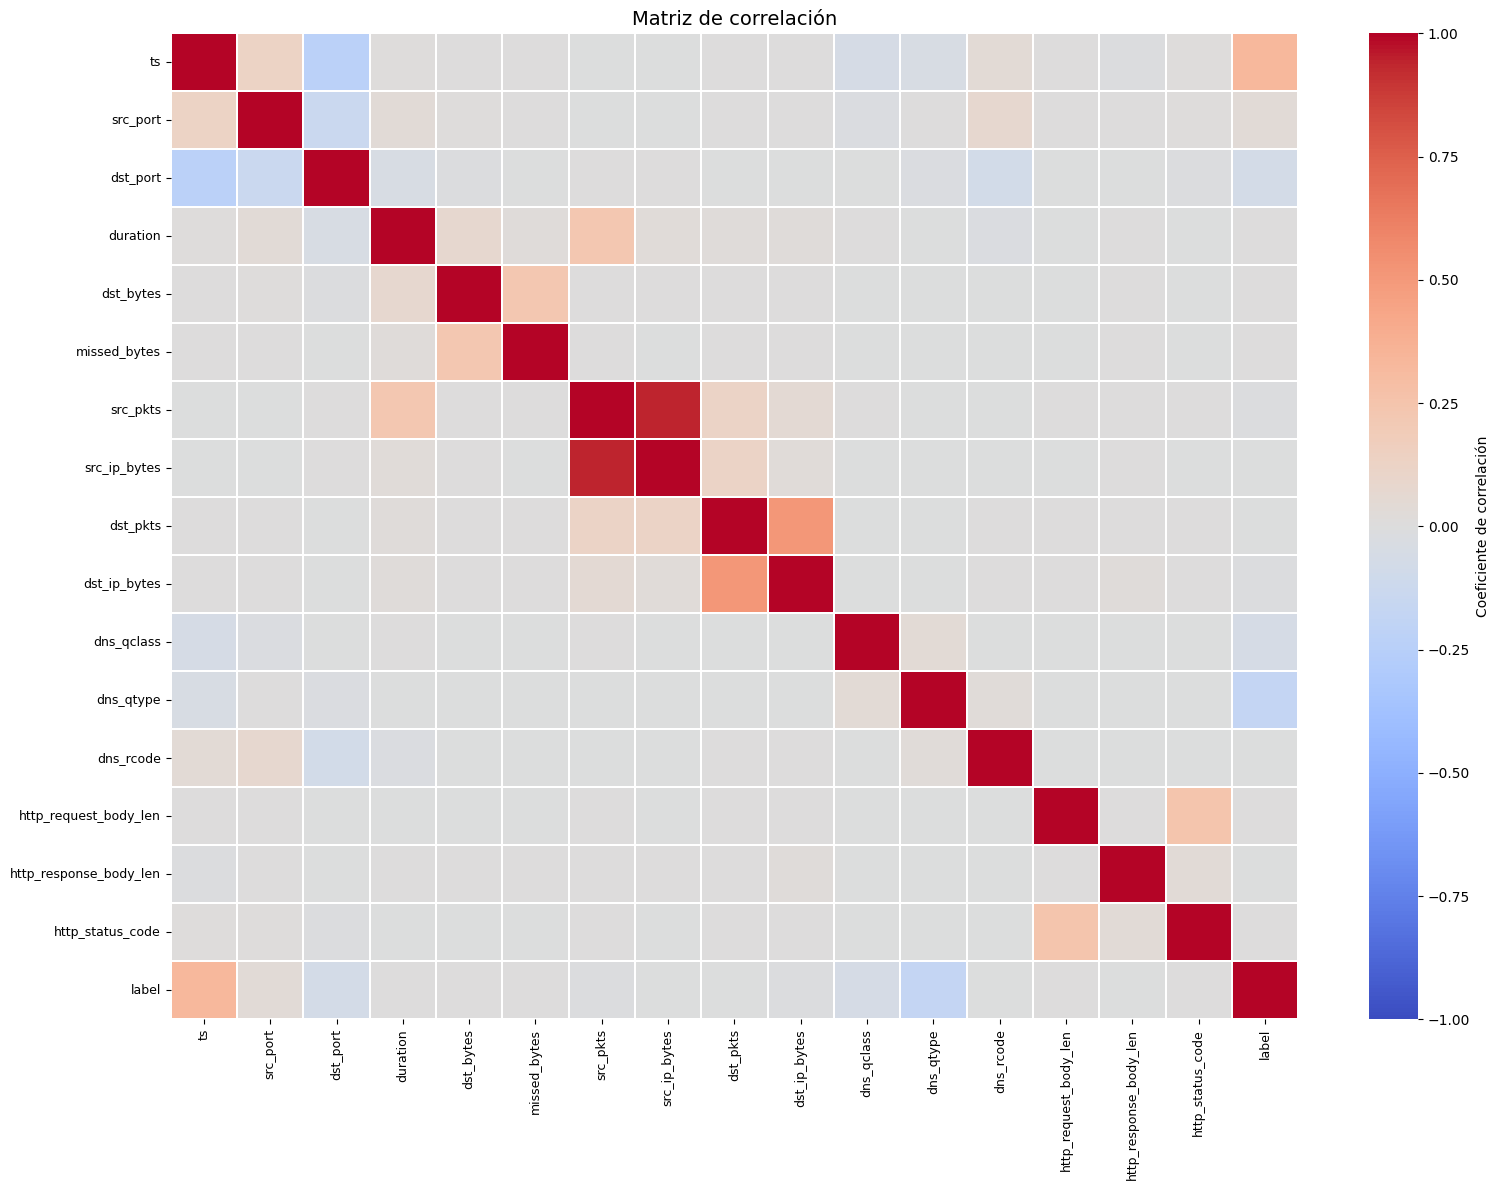

Imagen guardada en: ../images/figura_03_matriz_correlacion_full_sample_completa.png


In [63]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

IMAGE_DIR = "../images"
os.makedirs(IMAGE_DIR, exist_ok=True)

ruta_imagen = os.path.join(
    IMAGE_DIR,
    "figura_03_matriz_correlacion_full_sample_completa.png"
)

# ---------------------------------------------------
# Calcula la matriz de correlación usando TODOS los datos
# de df_full_sample y solo las variables numéricas
# ---------------------------------------------------
corr = df_full_sample[numeric_cols].corr()

# ---------------------------------------------------
# Decide si mostrar valores dentro del heatmap
# Si tienes muchas variables, puede saturarse visualmente
# ---------------------------------------------------
mostrar_valores = len(numeric_cols) <= 15

# ---------------------------------------------------
# Dibuja el heatmap de correlación
# ---------------------------------------------------
plt.figure(figsize=(16, 12))

ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=mostrar_valores,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"label": "Coeficiente de correlación"}
)

plt.title("Matriz de correlación", fontsize=14)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()

plt.savefig(
    ruta_imagen,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Imagen guardada en: {ruta_imagen}")

12. Gráfico de distribución de protocolos de red

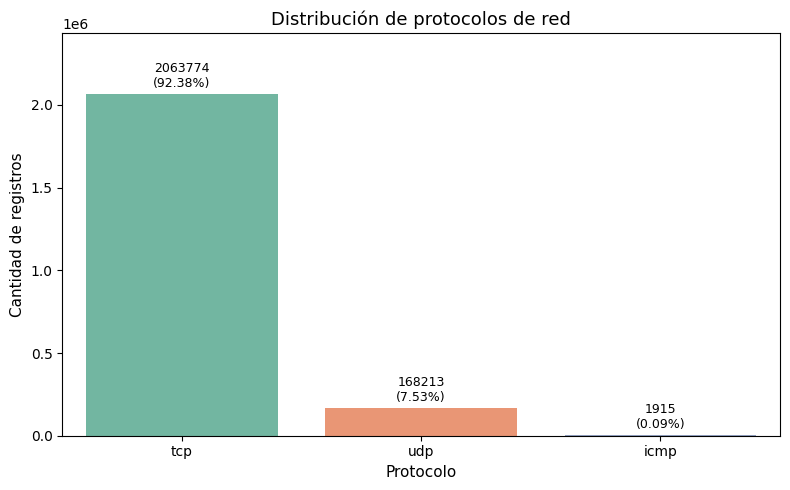

Imagen guardada en: ../images/figura_05_distribucion_protocolos.png


In [61]:

IMAGE_DIR = "../images"
os.makedirs(IMAGE_DIR, exist_ok=True)

ruta_imagen = os.path.join(
    IMAGE_DIR,
    "figura_05_distribucion_protocolos.png"
)

orden_proto = df_full_sample["proto"].value_counts().index
total = len(df_full_sample)

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_full_sample,
    x="proto",
    hue="proto",
    order=orden_proto,
    palette="Set2",
    legend=False
)

# Agregar cantidad + porcentaje sobre cada barra
for patch in ax.patches:
    altura = patch.get_height()
    if altura > 0:
        porcentaje = (altura / total) * 100
        ax.annotate(
            f"{int(altura)}\n({porcentaje:.2f}%)",
            (patch.get_x() + patch.get_width() / 2, altura),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

ax.set_ylim(0, df_full_sample["proto"].value_counts().max() * 1.18)

plt.title("Distribución de protocolos de red", fontsize=13)
plt.xlabel("Protocolo", fontsize=11)
plt.ylabel("Cantidad de registros", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.savefig(
    ruta_imagen,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Imagen guardada en: {ruta_imagen}")

13. Distribución de la duración de los tipos de ataque

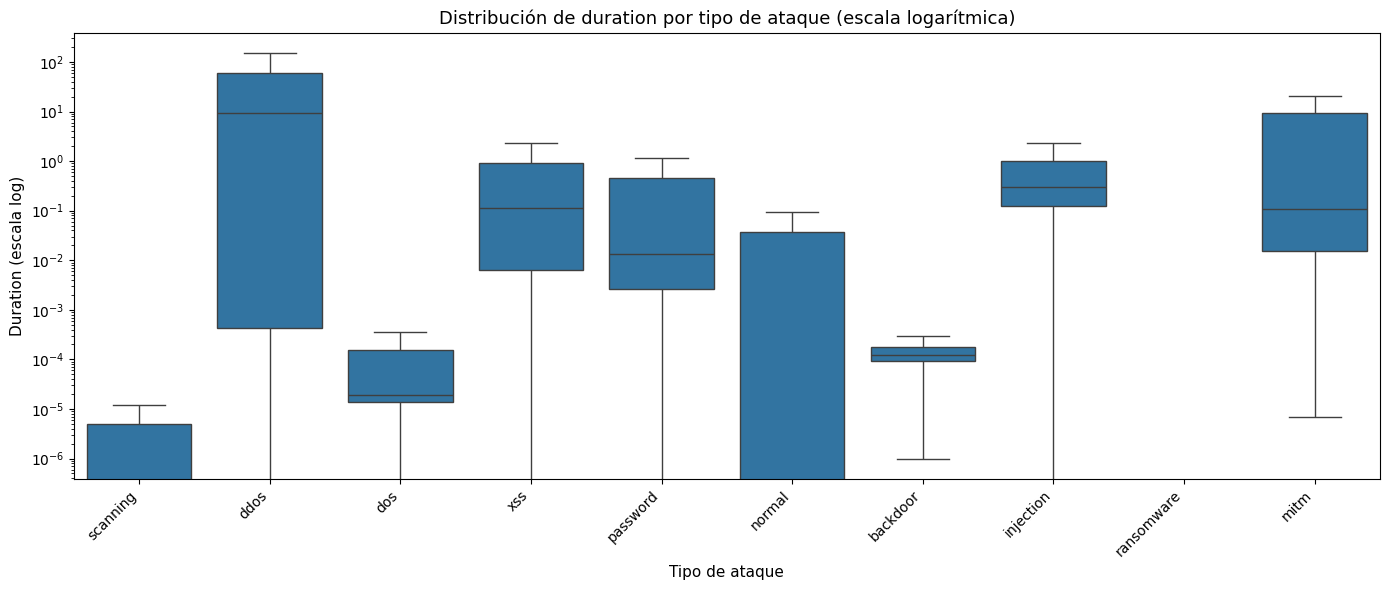

Imagen guardada en: ../images/figura_boxplot_duration_por_tipo_log.png


In [55]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

IMAGE_DIR = "../images"
os.makedirs(IMAGE_DIR, exist_ok=True)

ruta_imagen = os.path.join(
    IMAGE_DIR,
    "figura_boxplot_duration_por_tipo_log.png"
)

# Tomar solo los tipos más frecuentes para que no se vea saturado
top_tipos = df_full_sample["type"].value_counts().head(10).index
df_plot = df_full_sample[df_full_sample["type"].isin(top_tipos)].copy()

plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    data=df_plot,
    x="type",
    y="duration",
    order=top_tipos,
    showfliers=False
)

plt.yscale("log")
plt.title("Distribución de duration por tipo de ataque (escala logarítmica)", fontsize=13)
plt.xlabel("Tipo de ataque", fontsize=11)
plt.ylabel("Duration (escala log)", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.savefig(
    ruta_imagen,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Imagen guardada en: {ruta_imagen}")

14. OUTLIERS EN VARIABLES CLAVE

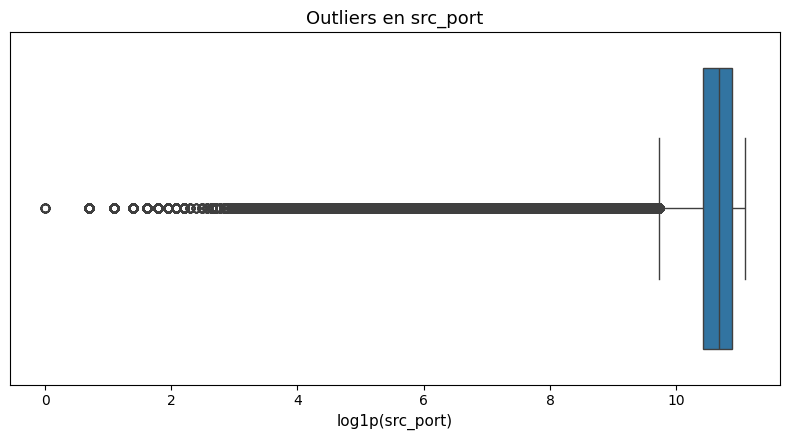

Imagen guardada en: ../images/boxplot_src_port_log1p.png


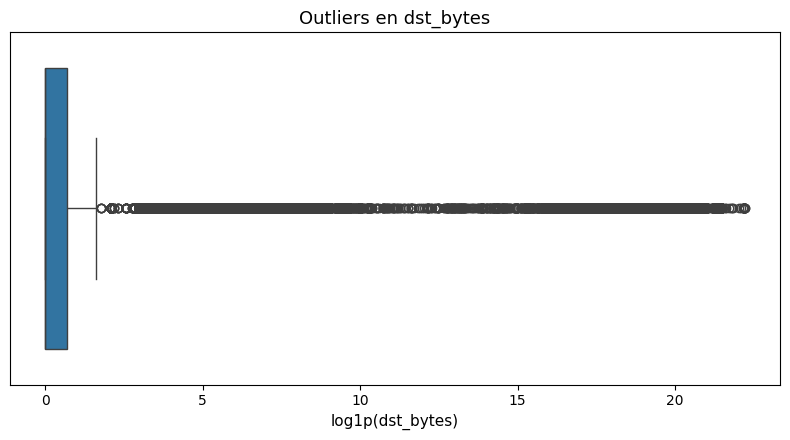

Imagen guardada en: ../images/boxplot_dst_bytes_log1p.png


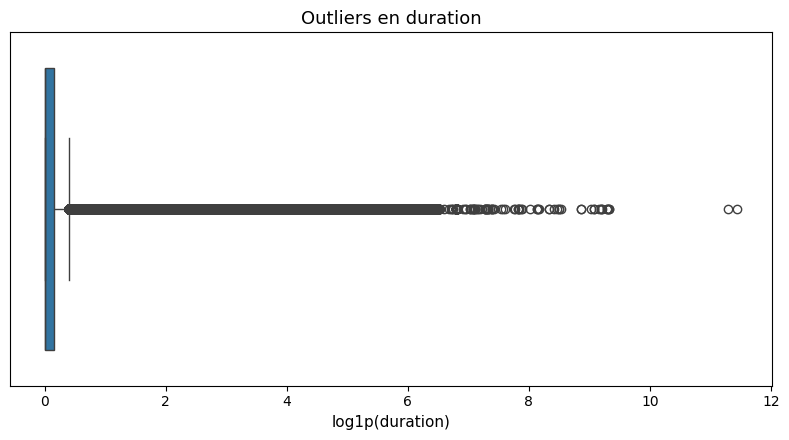

Imagen guardada en: ../images/boxplot_duration_log1p.png


In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IMAGE_DIR = "../images"
os.makedirs(IMAGE_DIR, exist_ok=True)

# ---------------------------------------------------
# Boxplots para detectar valores extremos
# en variables numéricas importantes
# con manejo automático de escala logarítmica
# ---------------------------------------------------
for col in cols_to_plot:
    if col in df_full_sample.columns:
        
        # Convertir a numérico por seguridad
        serie = pd.to_numeric(df_full_sample[col], errors="coerce").dropna()
        
        # Saltar si no hay datos
        if serie.empty:
            print(f"No se pudo graficar {col}: sin datos numéricos válidos.")
            continue
        
        plt.figure(figsize=(8, 4.5))
        
        # Caso 1: todos los valores son mayores a 0
        if (serie > 0).all():
            ax = sns.boxplot(x=serie)
            ax.set_xscale("log")
            
            plt.title(f"Outliers en {col}", fontsize=13)
            plt.xlabel(f"{col} (escala log)", fontsize=11)
            
            nombre_archivo = os.path.join(
                IMAGE_DIR,
                f"boxplot_{col}_log.png"
            )
        
        # Caso 2: hay ceros o mezcla de valores no negativos
        elif (serie >= 0).all():
            serie_log = np.log1p(serie)
            
            ax = sns.boxplot(x=serie_log)
            
            plt.title(f"Outliers en {col}", fontsize=13)
            plt.xlabel(f"log1p({col})", fontsize=11)
            
            nombre_archivo = os.path.join(
                IMAGE_DIR,
                f"boxplot_{col}_log1p.png"
            )
        
        # Caso 3: hay valores negativos
        else:
            # En este caso no conviene usar log directamente
            ax = sns.boxplot(x=serie)
            
            plt.title(f"Outliers en {col}", fontsize=13)
            plt.xlabel(col, fontsize=11)
            
            nombre_archivo = os.path.join(
                IMAGE_DIR,
                f"boxplot_{col}_normal.png"
            )
        
        plt.yticks([])
        plt.tight_layout()
        
        plt.savefig(
            nombre_archivo,
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()
        
        print(f"Imagen guardada en: {nombre_archivo}")

15. DUPLICADOS

In [57]:
# ---------------------------------------------------
# Cuenta cuántas filas duplicadas hay en la muestra
# Esto ayuda a evaluar si conviene eliminar duplicados
# más adelante en preprocessing
# ---------------------------------------------------
print("Duplicados en muestra full:", df_full_sample.duplicated().sum())

Duplicados en muestra full: 56312


16. GUARDAR LA MUESTRA EDA

In [58]:
df_full_sample["src_bytes"] = pd.to_numeric(df_full_sample["src_bytes"], errors="coerce")
# ---------------------------------------------------
# Crea la carpeta processed si no existe
# ---------------------------------------------------
os.makedirs(config.PROCESSED_PATH, exist_ok=True)

# ---------------------------------------------------
# Guarda la muestra del EDA en parquet para reutilizarla
# después sin volver a cargar los 23 CSV
# ---------------------------------------------------
df_full_sample.to_parquet(config.FULL_SAMPLE_PATH, index=False)

print("Muestra full guardada en:", config.FULL_SAMPLE_PATH)

Muestra full guardada en: /home/bryan_santanderaragon/Proyecto_MBD/data/processed/network_full_sample.parquet
